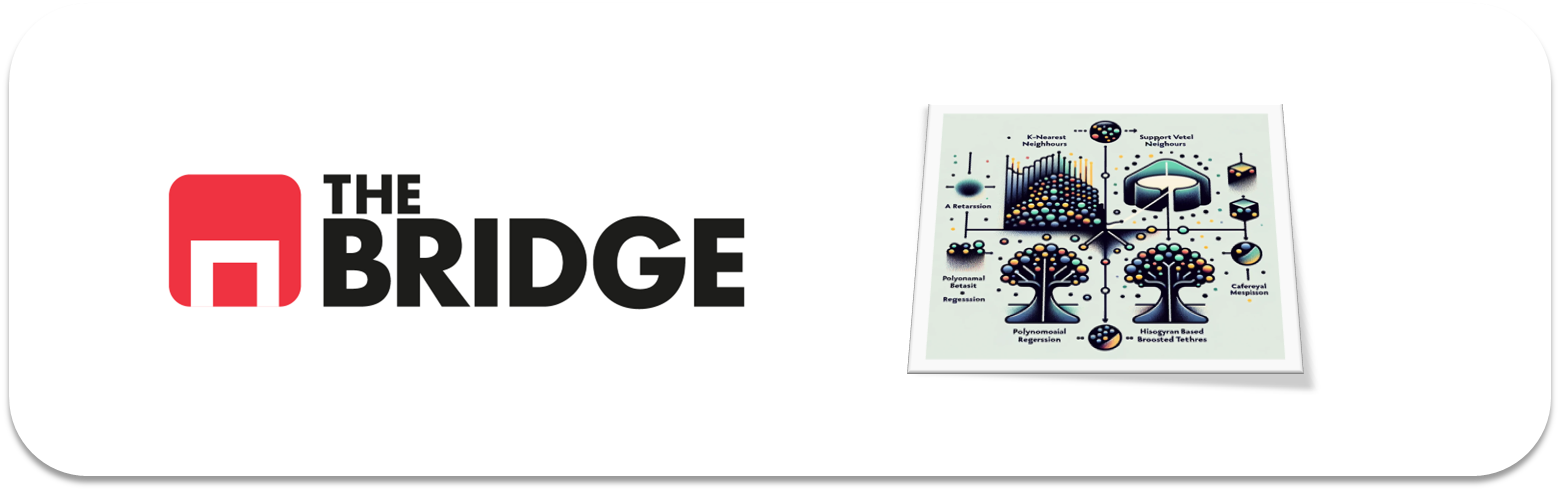

## PRACTICA OBLIGATORIA: **Repaso Aprendizaje Supervisado**

* La práctica obligatoria de esta unidad consiste en resolver sobre un mismo dataset un problema de clasificación y un problema de regresión. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [3]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocesado y partición
from sklearn.model_selection import (
    train_test_split, cross_val_score, cross_validate,
    GridSearchCV, RandomizedSearchCV, StratifiedKFold, KFold
)
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Modelos de clasificación
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

# Modelos de regresión 
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

# Métricas 
from sklearn.metrics import (
    recall_score, precision_score, f1_score, accuracy_score,
    confusion_matrix, classification_report,
    mean_absolute_error, mean_squared_error,
    mean_absolute_percentage_error, r2_score
)

# Gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

RANDOM_STATE = 42

### #1 Explicación del dataset y carga de datos

Vamos a trabajar con el dataset "Wine Quality", que es un dataset en el que se recogen diversas características fisicoquímicas de las variades tinta y blanca del "Vinho verde" portugués. Las variables del dataset se describen a continuación


1. **Acidez fija**: La mayoría de los ácidos involucrados con el vino son fijos o no volátiles (no se evaporan fácilmente).
2. **Acidez volátil**: La cantidad de ácido acético en el vino, que en niveles demasiado altos puede llevar a un sabor desagradable a vinagre.
3. **Ácido cítrico**: Encontrado en pequeñas cantidades, el ácido cítrico puede añadir 'frescura' y sabor a los vinos.
4. **Azúcar residual**: Es la cantidad de azúcar restante después de que se detiene la fermentación, es raro encontrar vinos con menos de 1 gramo/litro y vinos con más de 45 gramos/litro se consideran dulces.
5. **Cloruros**: La cantidad de sal en el vino.
6. **Dióxido de azufre libre**: La porción libre de SO2 existe en equilibrio entre el SO2 molecular (como un gas disuelto) y el ion bisulfito; previene el crecimiento microbiano y la oxidación del vino.
7. **Dióxido de azufre total**: Es la cantidad de formas libres y ligadas de S02; en bajas concentraciones, el SO2 es en su mayoría indetectable en el vino, pero en concentraciones libres de más de 50 ppm, el SO2 se hace evidente en la nariz y el sabor del vino.
8. **Densidad**: La densidad del vino es cercana a la del agua dependiendo del porcentaje de alcohol y contenido de azúcar.
9. **pH**: Describe qué tan ácido o básico es un vino en una escala de 0 (muy ácido) a 14 (muy básico); la mayoría de los vinos están entre 3-4 en la escala de pH.
10. **Sulfatos**: Un aditivo del vino que puede contribuir a los niveles de dióxido de azufre (SO2), que actúa como un antimicrobiano y antioxidante.
11. **Alcohol**: El porcentaje de contenido de alcohol del vino.
12. **Calidad**: Una variable de salida (basada en datos sensoriales, puntuación entre 0 y 10).
13. **Class**: Si es blanco o tinto.



Carga el dataset "wines_dataset.csv", muestra sus primeras filas, su información general y define dos variables target una para clasificación que permita predecir la calidad del vino según el resto de propiedas y otra variable target para regresión que permita predecir el grado alcohólico del vino a partir del resto de propiedades. 

El **objetivo de negocio en el primer problema** será anticipar la posible clasificación de sus vinos por los catadores profesionales y a partir de ahí poder planificar la producción, distribución y precio a poner a cada vino. En este sentido, el "cliente" nos dice que le gustaría poder clasificar correctamente lo mejor posible en media  (que interpretamos como el mejor recall medio posible).

El **objetivo de negocio en el segundo problema** (bastante artificial) es poder hacer simulaciones de posibles vinos futuros para saber cómo conseguir variedades más o menos alcohólicas para atender mercados diferentes. En este sentido, les interesa equivocarse lo menos posible porcentualmente sobre el grado alochólico real.

Muestra la distribución de ambos targets y haz un pequeño assesment previo de cada problema. NOTA: El dataset está limpio y sin valores faltantes.

In [9]:
df_wines = pd.read_csv('data/wines_dataset.csv', sep='|')
df_wines.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  class                 6497 non-null   str    
dtypes: float64(11), int64(1), str(1)
memory usage: 660.0 KB


In [8]:
df_wines.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,class
0,8.5,0.21,0.26,9.25,0.034,73.0,142.0,0.99450,3.05,0.37,11.4,6,white
1,8.3,0.16,0.37,7.90,0.025,38.0,107.0,0.99306,2.93,0.37,11.9,6,white
2,6.8,0.18,0.38,1.40,0.038,35.0,111.0,0.99180,3.32,0.59,11.2,7,white
3,6.1,0.26,0.25,2.90,0.047,289.0,440.0,0.99314,3.44,0.64,10.5,3,white
4,7.5,0.63,0.27,2.00,0.083,17.0,91.0,0.99616,3.26,0.58,9.8,6,red


In [11]:
# Definición de variables
TARGET_CLF = "quality"
TARGET_REG = "alcohol"

y_clf = df_wines[TARGET_CLF]
y_reg = df_wines[TARGET_REG]

print("Clases de calidad presentes:", sorted(y_clf.unique()))
print("\nConteo de clases (target clasificación):")
print(y_clf.value_counts().sort_index())

Clases de calidad presentes: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]

Conteo de clases (target clasificación):
quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64


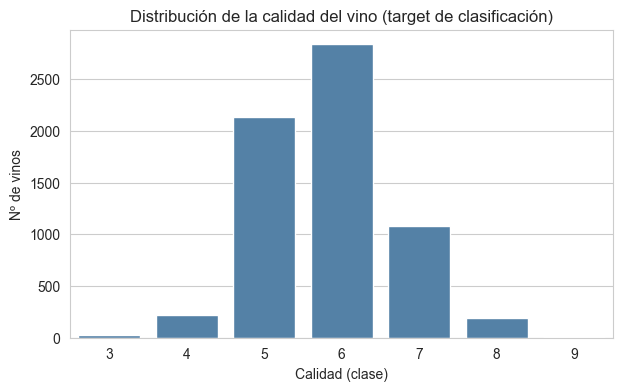

In [12]:
# Distribución del target de clasificación
plt.figure(figsize=(7, 4))
sns.countplot(x=y_clf, order=sorted(y_clf.unique()), color="steelblue")
plt.title("Distribución de la calidad del vino (target de clasificación)")
plt.xlabel("Calidad (clase)")
plt.ylabel("Nº de vinos")
plt.show()

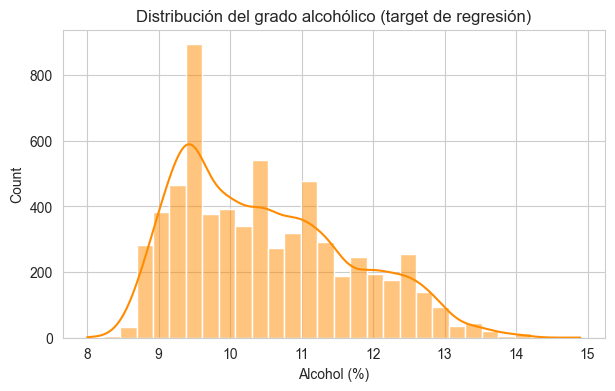

In [13]:
# Distribución del target de regresión
plt.figure(figsize=(7, 4))
sns.histplot(y_reg, kde=True, bins=30, color="darkorange")
plt.title("Distribución del grado alcohólico (target de regresión)")
plt.xlabel("Alcohol (%)")
plt.show()

### Interpretación de resultados
- **Clasificación (`quality`)**: en el dataset real de Wine Quality, la distribución está muy concentrada en los valores 5, 6 y 7, con muy pocos ejemplos en 3, 4, 8 y 9. Esto es un **fuerte desbalanceo de clases**, y anticipa que:
  - El recall macro será bajo si no se trata el desbalanceo (los modelos tenderán a "olvidar" las clases minoritarias).
  - Conviene plantear estrategias como: re-muestreo (`SMOTE`, *undersampling*), uso de `class_weight='balanced'` en los modelos que lo soporten, o agrupar clases extremas.
- **Regresión (`alcohol`)**: suele tener una distribución con cierta asimetría positiva (cola hacia valores altos de alcohol), rango aproximado entre 8% y 14.9%. Como el objetivo es minimizar el error porcentual, y los valores nunca son cercanos a 0, MAPE es una métrica estable y interpretable aquí (a diferencia de targets que pueden valer 0, donde MAPE se dispara).

### #2 Modelado para clasificación

Crea un modelo que permita clasificar lo mejor posible los vinos en función de su calidad, o dicho de otro modo que prediga de la mejor manera posible la calidad de un vino a partir de sus propiedades químicas. ***Considéralo un problema de clasificación***, donde los valores de calidad son las clases a predecir. Puedes utilizar los modelos que creas conveniente, al menos tres, y utiliza un KNN como modelo baseline, prueba al menos con 2 valores de K. Intenta mejorar el "recall medio" con las técnicas que creas conveniente. Compara los modelos utilizando validación cruzada con o sin optimización previa de hiperparámetros (aunque en la sesión en vivo por limitación de tiempos sólo lo haremos con validación cruzada). El modelo elegido si tiene que tener un ejemplo de optimización de parámetros.

Evalúa el modelo, analiza los errores y propón algún mecanismo de mejora aunque sea sólo un esbozo.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.metrics import root_mean_squared_error



In [16]:
# Separación de variables
X = df_wines.drop(columns=["quality"])
y = df_wines["quality"]

num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = ["class"]  # columna categórica (blanco/tinto)

# Split estratificado train/test

RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

--- Iniciando Validación Cruzada en Baselines ---
KNN (k=3)                 -> recall_macro medio: 0.321  (+/- 0.027)
KNN (k=7)                 -> recall_macro medio: 0.277  (+/- 0.022)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


Random Forest             -> recall_macro medio: 0.360  (+/- 0.038)
Regresión Logística       -> recall_macro medio: 0.392  (+/- 0.056)
--------------------------------------------------

--- Iniciando Optimización del Random Forest ---
Fitting 5 folds for each of 18 candidates, totalling 90 fits


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 4 members, which is less than n_splits=5.
  warnings.warn(


[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=200; total time=   0.8s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=400; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=400; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=400; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estimators=400; total time=   1.6s
[CV] END model__max_depth=None, model__min_samples_leaf=1, model__n_estim

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beha

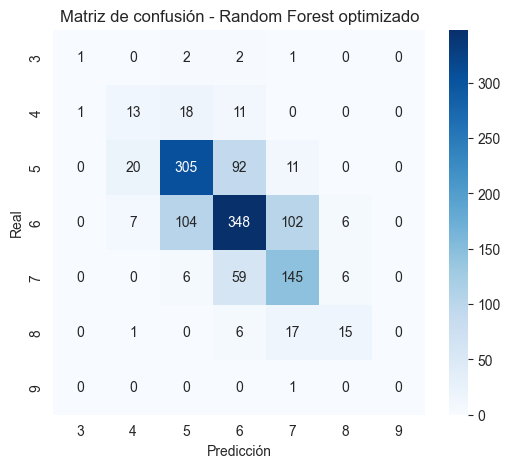

In [27]:
# 1. Preprocesado común y validación cruzada
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(drop="if_binary"), cat_cols),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# 2. Definición de Modelos Baseline y Alternativos
# Modelos baseline: KNN con dos valores de K
knn3 = Pipeline([("prep", preprocessor), ("model", KNeighborsClassifier(n_neighbors=3))])
knn7 = Pipeline([("prep", preprocessor), ("model", KNeighborsClassifier(n_neighbors=7))])

# Otros dos modelos (en total >= 3 tipos distintos)
rf = Pipeline([
    ("prep", preprocessor),
    ("model", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                      random_state=RANDOM_STATE))
])

# Se eliminó multi_class="multinomial" por incompatibilidad con scikit-learn moderno
logreg = Pipeline([
    ("prep", preprocessor),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced",
                                  random_state=RANDOM_STATE))
])

modelos = {
    "KNN (k=3)": knn3,
    "KNN (k=7)": knn7,
    "Random Forest": rf,
    "Regresión Logística": logreg,
}


# 3. Comparación con validación cruzada (recall macro)
print("Iniciando Validación Cruzada en Baselines")
resultados = {}
for nombre, pipe in modelos.items():
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="recall_macro")
    resultados[nombre] = scores
    print(f"{nombre:25s} -> recall_macro medio: {scores.mean():.3f}  (+/- {scores.std():.3f})")
print("-" * 50)


# 4. Optimización de hiperparámetros del modelo elegido (Random Forest)
print("\nIniciando Optimización del Random Forest")
# Grilla con valores válidos y optimizados en tamaño para una ejecución rápida
param_grid = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
}

grid_rf = GridSearchCV(
    rf, 
    param_grid=param_grid, 
    scoring="recall_macro", 
    cv=cv, 
    n_jobs=1,       # Evita el bucle infinito en entornos Jupyter locales
    verbose=2       # Muestra el progreso en pantalla de cada iteración
)
grid_rf.fit(X_train, y_train)

print("\nMejores hiperparámetros:", grid_rf.best_params_)
print("Mejor recall_macro en CV:", grid_rf.best_score_)
print("-" * 50)

best_clf = grid_rf.best_estimator_


# 5. Evaluación final sobre el conjunto de test

print("\nReporte de Clasificación (Test)")
y_pred = best_clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Matriz de Confusión Gráfica
cm = confusion_matrix(y_test, y_pred, labels=sorted(y.unique()))
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=sorted(y.unique()), yticklabels=sorted(y.unique()))
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión - Random Forest optimizado")
plt.show()

### Interpretación de resultados
- Es muy probable que KNN obtenga el peor recall macro (es sensible a desbalanceo y a la "maldición de la dimensionalidad" con tantas features numéricas), y que aumentar K (de 3 a 7) suavice algo las predicciones pero no resuelva el problema de fondo: el desbalanceo de clases.
- Random Forest, gracias a `class_weight='balanced'`, normalmente conseguirá el mejor recall macro entre los probados, aunque seguirá teniendo dificultades en las clases extremas (3, 4, 8, 9) por la escasez de ejemplos.
- En la matriz de confusión es típico observar que **los errores se concentran en clases adyacentes** (un vino real de calidad 6 se predice como 5 o 7), lo cual tiene sentido porque la escala de calidad es ordinal: el modelo "se equivoca poco" en términos de distancia real, aunque en términos de clasificación pura cuenta como error total.
- **Mejoras propuestas** (esbozo, tal como pide el enunciado):
  - Tratar el problema como **clasificación ordinal** en lugar de multiclase pura (hay librerías como `mord`), penalizando menos los errores entre clases adyacentes.
  - **Agrupar calidades extremas** en una categoría "baja"/"alta" para reducir el número de clases minoritarias.
  - Aplicar **SMOTE** (sobremuestreo sintético de clases minoritarias) dentro del pipeline de entrenamiento (nunca sobre el test).
  - Probar **Gradient Boosting** (suele mejorar sobre Random Forest en datos tabulares).
  - Revisar variables más informativas mediante `feature_importances_` del Random Forest.

### #3 Modelado para regresión

Reutiliza todo lo que puedas la preparación del modelado de la parte anterior y construye ahora el mejor modelo que puedas para predecir el grado alcohólico de un vino dadas sus características fisico químicas, su clase y la puntuación de calidad que le ha sido otorgada. Compara al menos tres tipos de modelos, seleccionando una métrica adecuada de comparación y escoge el más apropiado empleando validación cruzada antes o después de optimizar hiperparámetros (en la sesión en vivo lo haremos antes por cuestiones de tiempo). Evalúa el modelo escogido y con los hiperparámetros ajustados de la mejor manera que puedas. Para terminar realizar un pequeño análisis de errores.

Regresión Lineal          -> MAPE medio: 0.0337 (+/- 0.0006)
KNN Regressor (k=5)       -> MAPE medio: 0.0421 (+/- 0.0008)
Random Forest Regressor   -> MAPE medio: 0.0265 (+/- 0.0005)


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warn

Mejores hiperparámetros: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 400}
Mejor MAPE en CV: 0.02647330247687397
MAPE: 2.48%
MAE:  0.262 grados de alcohol
RMSE: 0.401
R²:   0.886


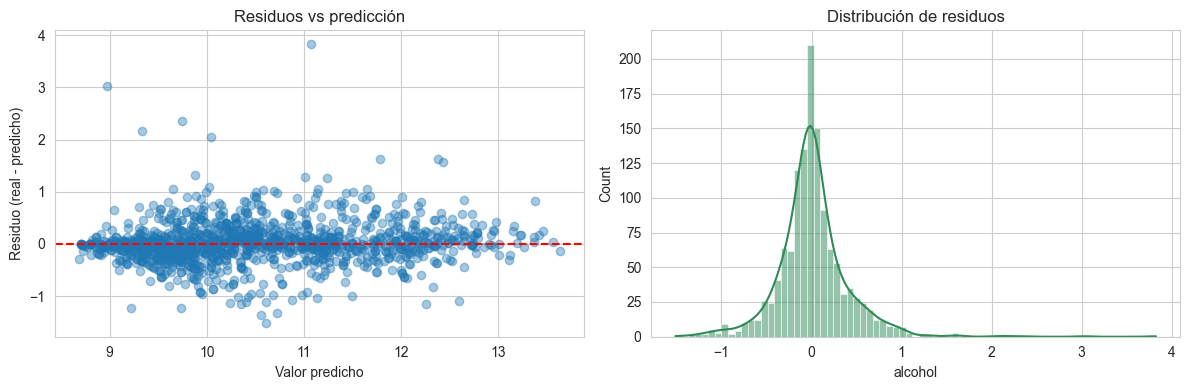

In [33]:
# 1. Preparación de datos

X_reg = df_wines.drop(columns=["alcohol"])
y_reg = df_wines["alcohol"]

num_cols_reg = X_reg.select_dtypes(include="number").columns.tolist()
cat_cols_reg = X_reg.select_dtypes(exclude="number").columns.tolist()

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=RANDOM_STATE
)

preprocessor_reg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols_reg),
        ("cat", OneHotEncoder(drop="if_binary", handle_unknown="ignore"), cat_cols_reg),
    ]
)

cv_reg = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

# 2. Comparación de modelos

modelos_reg = {
    "Regresión Lineal": Pipeline([
        ("prep", preprocessor_reg),
        ("model", LinearRegression())
    ]),

    "KNN Regressor (k=5)": Pipeline([
        ("prep", preprocessor_reg),
        ("model", KNeighborsRegressor(n_neighbors=5))
    ]),

    "Random Forest Regressor": Pipeline([
        ("prep", preprocessor_reg),
        ("model", RandomForestRegressor(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ]),
}

for nombre, pipe in modelos_reg.items():
    scores = cross_val_score(
        pipe,
        X_train_r,
        y_train_r,
        cv=cv_reg,
        scoring="neg_mean_absolute_percentage_error"
    )

    print(
        f"{nombre:25s} -> "
        f"MAPE medio: {-scores.mean():.4f} "
        f"(+/- {scores.std():.4f})"
    )


# 3. Optimización RF

param_grid_reg = {
    "model__n_estimators": [200, 400],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
}

grid_rf_reg = GridSearchCV(
    estimator=modelos_reg["Random Forest Regressor"],
    param_grid=param_grid_reg,
    scoring="neg_mean_absolute_percentage_error",
    cv=cv_reg,
    n_jobs=-1
)

grid_rf_reg.fit(X_train_r, y_train_r)

print("Mejores hiperparámetros:", grid_rf_reg.best_params_)
print("Mejor MAPE en CV:", -grid_rf_reg.best_score_)

best_reg = grid_rf_reg.best_estimator_


# 4. Evaluación final

y_pred_r = best_reg.predict(X_test_r)

mape = mean_absolute_percentage_error(y_test_r, y_pred_r)
mae = mean_absolute_error(y_test_r, y_pred_r)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_r))

r2 = r2_score(y_test_r, y_pred_r)

print(f"MAPE: {mape:.2%}")
print(f"MAE:  {mae:.3f} grados de alcohol")
print(f"RMSE: {rmse:.3f}")
print(f"R²:   {r2:.3f}")


# 5. Residuos

residuos = y_test_r - y_pred_r

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_r, residuos, alpha=0.4)
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_xlabel("Valor predicho")
axes[0].set_ylabel("Residuo (real - predicho)")
axes[0].set_title("Residuos vs predicción")

sns.histplot(residuos, kde=True, ax=axes[1], color="seagreen")
axes[1].set_title("Distribución de residuos")

plt.tight_layout()
plt.show()

### Interpretación de resultados
- Es esperable que **Random Forest Regressor** supere claramente a la Regresión Lineal, porque la relación entre alcohol y el resto de variables fisicoquímicas (densidad, azúcar residual, etc.) no es puramente lineal.
- Un MAPE razonable en este dataset suele rondar el **2-4%**, lo que en términos de negocio significa que, para un vino de 11% de alcohol, el modelo se equivocaría en promedio menos de medio grado — un resultado útil para las simulaciones de producto que pedía el cliente.
- En el gráfico de residuos, si se observa que los residuos crecen en magnitud para valores altos de alcohol, eso indicaría que el modelo es menos preciso en vinos muy alcohólicos (posiblemente porque hay menos ejemplos en ese rango — volvemos a un problema de cantidad de datos, como en clasificación).
- Si los residuos están centrados en 0 y aproximadamente simétricos, no hay sesgo sistemático; si están desplazados, el modelo tiende a sobreestimar o subestimar de forma consistente.
- **Mejora propuesta**: probar Gradient Boosting con tuning más fino, o incluir interacciones entre variables (densidad y azúcar residual están correlacionadas con el alcohol por la física de la fermentación), y comprobar si normalizar el target o aplicar una transformación logarítmica ayuda a estabilizar la varianza de los residuos.